# MTY4-A0C: Random Walks Sample Solutions
by Sergio Eraso

A random walk is a stochastic process in which a walker — such as a particle or a person — follows a path consisting of a succession of random steps. A classic related example is the Brownian motion of particles suspended in a fluid, resulting from collisions with fast-moving molecules in the surrounding medium.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from IPython.display import display
#plt.rcParams["figure.figsize"] = (3,2)
#plt.rcParams["figure.dpi"] = 150

## Simulation

The one-dimensional random walk is constructed as follows:
1. Initialize the walker at a position $y_0 = 0$
2. Flip a fair coin ($p = \frac{1}{2}$):\
        a. if it’s heads, take one step right\
        b. if it’s tails, take one step left
3. Repeat this for $N$ steps

Steps should be of size $1$, but in general they can be of any size. If $u_i$ is the $i^{\text{th}}$ step, then the trajectory up to the $n^{\text{th}}$ step is
$$y_n = \sum_{i=1}^n u_i$$

To start, let us plot the probability distribution of a single step $u_i$. Remember that this is just the probability distribution of a coin toss.

Text(0, 0.5, 'Probability')

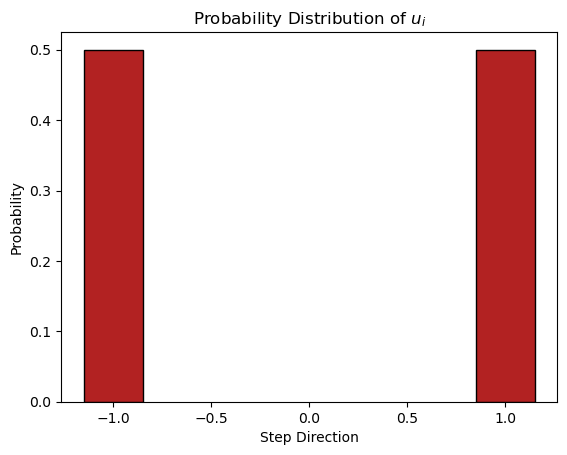

In [4]:
outcomes = [-1,1]
probabilities = [0.5, 0.5]
fig, ax = plt.subplots()
ax.bar(outcomes, probabilities, width=0.3, color="firebrick", edgecolor="black")
ax.set_title(r"Probability Distribution of $u_i$")
ax.set_xlabel("Step Direction")
ax.set_ylabel("Probability")

**[Task]** We will now implement the random walk in python with a function that we will call `randomwalk1d`. This function will keep track of the position of the particle at each step. We have the following arguments:

- `n_steps`: number of steps in the random walk
- `step_size`: distance moved each step (default value of 1)
- `p`: probability of moving to the right at each step (default value of 1/2 so the walk is symmetric)

In [5]:
def randomwalk1d(n_steps, step_size = 1, p = 1/2):
    """Generates the positions of a 1D random walk with probability p of moving to the right

    Args:
        n_steps (int): number of steps
        step_size (int, optional):  Defaults to 1.
        p (float, optional): probability of moving to the right

    Returns:
        ndarray: position of the random walker at each time step
    """
    # generate a list of steps
    directions = np.random.choice([-1,1], p = [1-p,p], size = n_steps)
    u = step_size*directions
    # generate positions for each time step
    positions = np.cumsum(u)
    # insert the initial position
    positions = np.insert(positions, 0, 0)
    return positions
        

## Measurements

Now that we have written the code for our simulation, we can take some measurements to better understand this system's behavior.

### Single Trajectory

**[Task]** Plot the trajectory a single random walker versus the number of steps for $N = 500$. Make sure your plot has appropriately labeled axes and a title.

In [6]:
positions = randomwalk1d(n_steps=500, step_size=1)

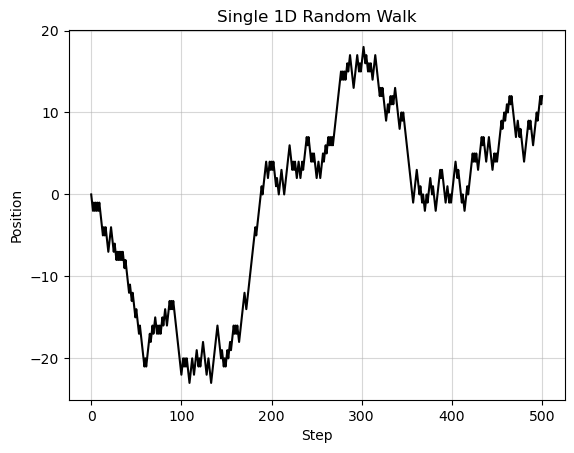

In [91]:
fig, ax = plt.subplots()
ax.plot(positions, color="black")
ax.set_title("Single 1D Random Walk")
ax.set_ylabel("Position")
ax.set_xlabel("Step")
ax.grid(alpha=0.5)

### Ensemble of Trajectories

**[Task]** Plot an ensemble of $1000$ trajectories with $N = 400$ on the same axes. Adjust the `alpha` of your plot to improve readability. 

Text(0, 0.5, 'Position')

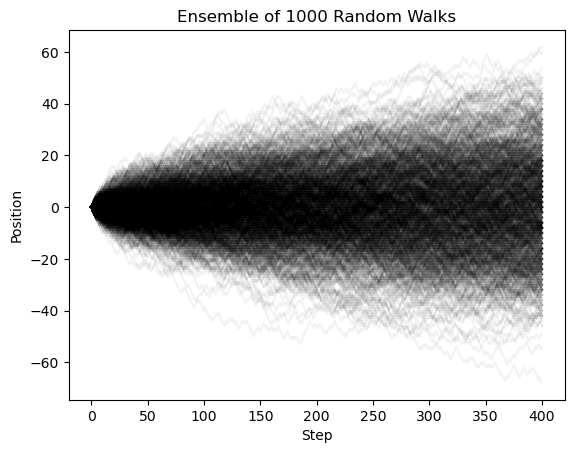

In [88]:
# create an ensemble of 1000 trajectories
n_trajs = 1000
n_steps = 400
walks = np.asarray([randomwalk1d(n_steps=n_steps) for i in range(n_trajs)])
# plot all of the trajectories on one set of axes
fig, ax = plt.subplots()
for walk in walks:
    ax.plot(walk, color="black", alpha=0.05)
ax.set_title(f"Ensemble of {n_trajs} Random Walks")
ax.set_xlabel("Step")
ax.set_ylabel("Position")

Even though the exact trajectory of a single random walker is hard to predict, we see that an ensemble of random walkers exhibits some patterns. For example, we can see that roughly half of the walkers end up above zero and half of them below zero. We also note that as the number of steps increases, more and more walkers get further away from zero. We can quantify this behavior by calculating the mean and standard deviation of our ensemble.

**[Task]** Numerically calculate the mean and standard deviation of your ensemble of random walks at each step.

In [26]:
# compute the mean of your ensemble at each step
mean_series = np.mean(walks, axis=0)
# compute the std of your ensemble at each step
std_series = np.std(walks, axis=0)

**[Task]** Overlay your calculated mean and standard deviation on the above plot. Make sure you include a legend.

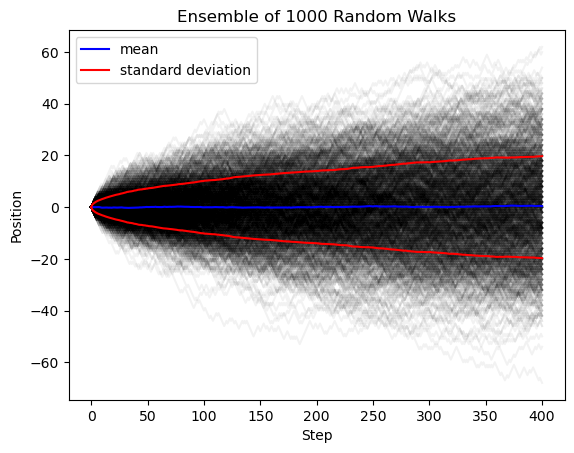

In [89]:
# create a plot of your ensemble including the lines for mean and standard deviation
ax.plot(mean_series, color= "blue", label="mean")
ax.plot(std_series, color = "red", label="standard deviation")
ax.plot(-std_series, color = "red")
ax.legend()
display(fig)

### Theory

We will now calculate the *exact* theoretical values of the mean and the standard deviation using the probability distribution for $u_i$. Feel free to calculate this yourself using the definitions of mean and standard deviation:
$$\langle x \rangle = \sum_i x_i p_i$$
$$\sigma^2 = \langle x^2 \rangle_c = \langle (x - \langle x \rangle)^2 \rangle_c = \sum_i (x_i - \langle x \rangle)^2 p_i$$

**[Task]** Create a plot comparing your theoretical prediction of the mean $\langle x \rangle$ to your experimental data

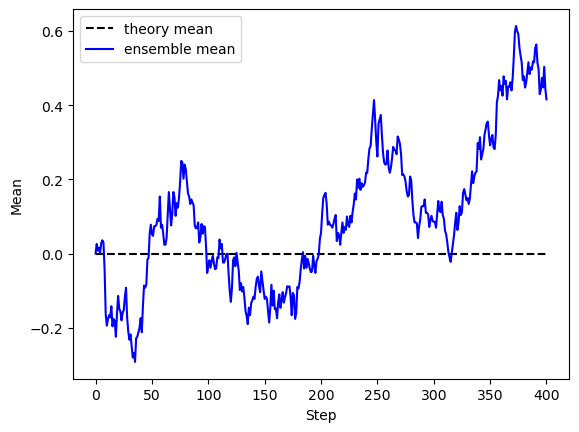

In [38]:
# plot of theory mean and experimental mean
N_values = np.arange(n_steps + 1)
theory_mean = np.zeros(n_steps + 1)
fig, ax = plt.subplots()
ax.plot(N_values, theory_mean, ls="--", color="black", label="theory mean")
ax.plot(N_values, mean_series, color="blue", label="ensemble mean")
ax.set_xlabel("Step")
ax.set_ylabel("Mean")
ax.set_ylim()
ax.legend()

**[Task]** Create a plot comparing your theoretical prediction of the standard deviation $\sigma = \sqrt{\langle x^2 \rangle_c}$ to your experimental data

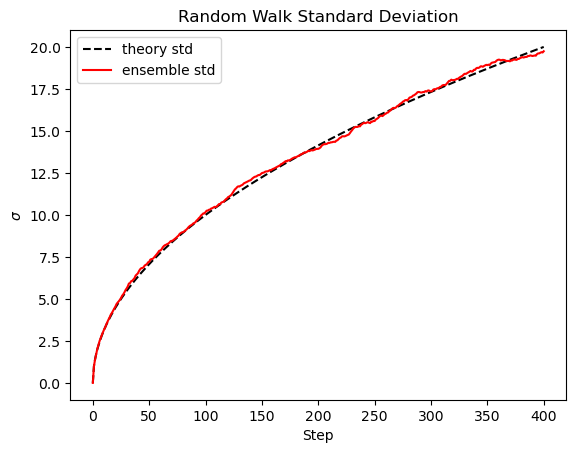

In [43]:
# plot of theory std and experimental std
fig, ax = plt.subplots()
theory_std = N_values**(1/2)
ax.plot(N_values, theory_std, ls="--", color="black", label="theory std")
ax.plot(N_values, std_series, color="red", label="ensemble std")
ax.set_title("Random Walk Standard Deviation")
ax.set_ylabel(r"$\sigma$")
ax.set_xlabel("Step")
ax.legend()

### Curve Fitting

Hopefully, your experimental standard deviation data aligns pretty well with the theoretical prediction. Let's try to be a little more quantitative by fitting our experimental data to a model that looks like our theoretical result

$$\sigma(N) = c N^{\alpha}$$

and then seeing how the experimental $\alpha_{\text{exp}}$ compares to the theoretical $\alpha_{\text{th}} = 1/2$. To do this, we will borrow a function from another popular Python package `scipy`.

In [44]:
# to obtain the exponent numerically, we import a nonlinear regression function
from scipy.optimize import curve_fit

**[Task]** Write the model as a Python function. It should depend on `c`, `N`, and `alpha`.

In [51]:
# create your model using the above equation
def power_law(N,c,alpha):
    return c*N**alpha

The function `curve_fit` will take our data fit it using the function `power_law`. It will then give us back the values of `c` and `alpha` that it found best fit the data. This is what we call $\alpha_{\text{exp}}$. The syntax for calling `curve_fit` is

`curve_fit(model, x_data, y_data)`

It returns an array of parameters and some other information that isn't relevant for us at the moment. 

In [59]:
params, _ = curve_fit(power_law, N_values, std_series)
c, alpha = params
print(f"c = {c} \nalpha = {alpha}")

c = 1.0457547409433907 
alpha = 0.4923879036375178


### Convergence to Normal Distribution by Central Limit Theorem

We will now observe the Central Limit Theorem (CLT) in action. Recall that the CLT says that if you sum up many random variables $x_i$ (independent and identically distributed), 

$$y = \sum_i x_i$$

then $y$ is itself a random variable that is distributed according to a normal (Gaussian) distribution (after appropriate scaling). We will borrow another function from `scipy` that will let us fit our data to a normal distribution.

In [60]:
# import scipy to fit the data to a normal (Gaussian) distribution
from scipy.stats import norm

To make the CLT very clear, we will generate a large number of data. 

**[Task]** Try running something on the order of $10^4$ trajectories each with $N = 10^4$. Save the final position of each trajectory into an array.

In [85]:
# generate a large ensemble of trajectories with many steps
n_trajs = 50000
n_steps = 10000
# save only the final position of each walker
final_positions = [randomwalk1d(n_steps)[-1] for _ in range(n_trajs)]
final_positions = np.asarray(final_positions)

**[Task]** We can now calculate a Gaussian fit using the function `norm.fit(data)`. This will return two values:
- `mu`: the estimated mean
- `sigma`: the estimated standard deviation

In [86]:
# fit the data
mu, sigma = norm.fit(final_positions)

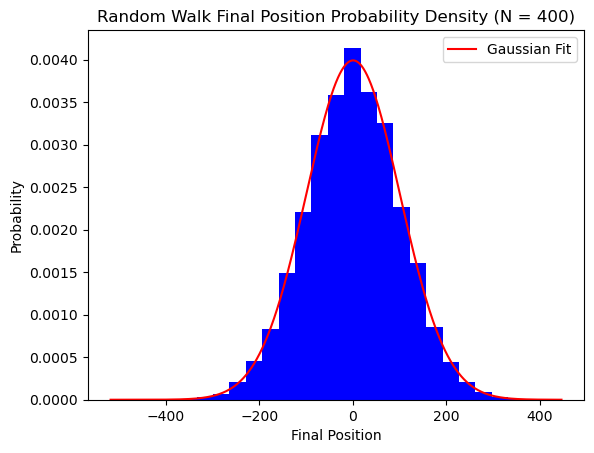

In [90]:
# plot the histogram of final positions
fig, ax = plt.subplots()
ax.hist(final_positions, bins = 25 , density=True, color="blue")     # density = True normalizes the histogram
# fit the data
mu, std = norm.fit(final_positions)     # returns the estimated parameters of the Gaussian fit
# obtain the range of x-values from the plot
xmin, xmax = ax.get_xlim()
xvals = np.linspace(xmin, xmax, 1000)
# plot the fit
gauss_fit = norm.pdf(xvals, loc=mu, scale=std)
ax.plot(xvals, gauss_fit, color="red", label="Gaussian Fit")

ax.set_title(f"Random Walk Final Position Probability Density (N = {n_steps})")
ax.set_xlabel("Final Position")
ax.set_ylabel("Probability")
ax.legend()

If you play around with the parameter `bins` in the `histogram` function, you might notice that for a large quantity of bins, we see "holes" and "spikes" in the histogram. Why is this?